# 02 - Feature Engineering

Bu notebook'ta `train.csv` üzerinde ML modellemesi için gerekli özellikler üretilecek:

1. **Tarih özellikleri** — ay, haftanın günü, hafta no, yıl, mevsim
2. **Lag özelikleri** — 7, 14, 30 günlük gecikmeli satışlar (store×item bazında)
3. **Rolling istatistikler** — 7, 14, 30, 90 günlük kayan ortalama / standart sapma
4. **Trend değişkenleri** — başlangıçtan geçen gün sayısı, yılın günü
5. **Çapraz özellikler** — store×item etkileşimi
6. **Çıktı** — `data/processed/train_features.parquet`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)

RAW_DIR       = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print('Kütüphaneler yüklendi.')

Kütüphaneler yüklendi.


## 1. Veri Yükleme

In [2]:
df = pd.read_csv(RAW_DIR / 'train.csv', parse_dates=['date'])
df = df.sort_values(['store', 'item', 'date']).reset_index(drop=True)

print(f'Shape  : {df.shape}')
print(f'Tarih  : {df.date.min().date()}  →  {df.date.max().date()}')
print(f'Store  : {df.store.nunique()}  |  Item: {df.item.nunique()}')
df.head()

Shape  : (913000, 4)
Tarih  : 2013-01-01  →  2017-12-31
Store  : 10  |  Item: 50


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


## 2. Tarih (Mevsimsellik) Özellikleri

In [3]:
def add_date_features(df: pd.DataFrame) -> pd.DataFrame:
    """Tarihten türetilen mevsimsellik ve takvim özellikleri."""
    d = df.copy()

    d['year']        = d['date'].dt.year
    d['month']       = d['date'].dt.month          # 1-12
    d['day']         = d['date'].dt.day             # 1-31
    d['day_of_week'] = d['date'].dt.dayofweek       # 0=Pzt … 6=Paz
    d['week_of_year']= d['date'].dt.isocalendar().week.astype(int)  # 1-53
    d['day_of_year'] = d['date'].dt.dayofyear       # 1-366
    d['quarter']     = d['date'].dt.quarter         # 1-4

    # İkili bayraklar
    d['is_weekend']  = (d['day_of_week'] >= 5).astype(int)
    d['is_month_start'] = d['date'].dt.is_month_start.astype(int)
    d['is_month_end']   = d['date'].dt.is_month_end.astype(int)

    # Mevsim: 1=Kış 2=İlkbahar 3=Yaz 4=Sonbahar
    d['season'] = d['month'].map({
        12: 1, 1: 1, 2: 1,
        3: 2,  4: 2, 5: 2,
        6: 3,  7: 3, 8: 3,
        9: 4, 10: 4, 11: 4
    })

    # Sinüs/Kosinüs kodlama — döngüsel değişkenler için
    d['month_sin']       = np.sin(2 * np.pi * d['month'] / 12)
    d['month_cos']       = np.cos(2 * np.pi * d['month'] / 12)
    d['day_of_week_sin'] = np.sin(2 * np.pi * d['day_of_week'] / 7)
    d['day_of_week_cos'] = np.cos(2 * np.pi * d['day_of_week'] / 7)
    d['week_of_year_sin']= np.sin(2 * np.pi * d['week_of_year'] / 52)
    d['week_of_year_cos']= np.cos(2 * np.pi * d['week_of_year'] / 52)

    return d

df = add_date_features(df)

date_cols = ['year','month','day','day_of_week','week_of_year','day_of_year',
             'quarter','is_weekend','is_month_start','is_month_end','season',
             'month_sin','month_cos','day_of_week_sin','day_of_week_cos',
             'week_of_year_sin','week_of_year_cos']
print(f'Eklenen tarih özellikleri ({len(date_cols)}): {date_cols}')
df[['date'] + date_cols[:8]].head()

Eklenen tarih özellikleri (17): ['year', 'month', 'day', 'day_of_week', 'week_of_year', 'day_of_year', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'season', 'month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos', 'week_of_year_sin', 'week_of_year_cos']


,date,year,month,day,day_of_week,week_of_year,day_of_year,quarter,is_weekend
0,2013-01-01,2013,1,1,1,1,1,1,0
1,2013-01-02,2013,1,2,2,1,2,1,0
2,2013-01-03,2013,1,3,3,1,3,1,0
3,2013-01-04,2013,1,4,4,1,4,1,0
4,2013-01-05,2013,1,5,5,1,5,1,1


## 3. Trend Değişkenleri

In [4]:
def add_trend_features(df: pd.DataFrame) -> pd.DataFrame:
    """Genel zaman trendi değişkenleri."""
    d = df.copy()

    origin = d['date'].min()

    # Başlangıçtan bu yana geçen gün sayısı (doğrusal trend)
    d['days_since_start'] = (d['date'] - origin).dt.days

    # Yıl içi göreceli pozisyon [0, 1]
    d['year_progress'] = (d['day_of_year'] - 1) / 365.0

    return d

df = add_trend_features(df)
print('Trend değişkenleri eklendi: days_since_start, year_progress')
df[['date','days_since_start','year_progress']].drop_duplicates('date').head(8)

Trend değişkenleri eklendi: days_since_start, year_progress


,date,days_since_start,year_progress
0,2013-01-01,0,0.000000
1,2013-01-02,1,0.002740
2,2013-01-03,2,0.005479
3,2013-01-04,3,0.008219
4,2013-01-05,4,0.010959
5,2013-01-06,5,0.013699
6,2013-01-07,6,0.016438
7,2013-01-08,7,0.019178


## 4. Lag Özellikleri (Store × Item bazında)

In [5]:
def add_lag_features(df: pd.DataFrame, lags) -> pd.DataFrame:
    """
    Her (store, item) grubu için belirtilen gecikme değerlerinde
    lag özelliği üretir.

    Veri zaten store→item→date sıralı olduğundan groupby+shift kullanılır.
    """
    d = df.copy()
    grp = d.groupby(['store', 'item'])['sales']

    for lag in lags:
        col = f'lag_{lag}'
        d[col] = grp.shift(lag)
        print(f'  {col}: NaN sayısı = {d[col].isna().sum():,}')

    return d

LAG_DAYS = [7, 14, 28, 30, 365]

print('Lag özellikleri oluşturuluyor...')
df = add_lag_features(df, lags=LAG_DAYS)
print(f'\nToplam lag özellikleri: {len(LAG_DAYS)}')

Lag özellikleri oluşturuluyor...
  lag_7: NaN sayısı = 3,500
  lag_14: NaN sayısı = 7,000
  lag_28: NaN sayısı = 14,000
  lag_30: NaN sayısı = 15,000
  lag_365: NaN sayısı = 182,500

Toplam lag özellikleri: 5


## 5. Rolling Ortalama & Standart Sapma

In [6]:
def add_rolling_features(df: pd.DataFrame, windows) -> pd.DataFrame:
    """
    Her (store, item) grubu için kayan pencere istatistikleri üretir.
    Veri sızıntısını önlemek için shift(1) uygulanır (bugünü dahil etmez).
    """
    d = df.copy()

    for w in windows:
        col_mean = f'rolling_mean_{w}'
        d[col_mean] = (
            d.groupby(['store', 'item'])['sales']
             .transform(lambda x: x.shift(1).rolling(window=w, min_periods=1).mean())
        )

        col_std = f'rolling_std_{w}'
        d[col_std] = (
            d.groupby(['store', 'item'])['sales']
             .transform(lambda x: x.shift(1).rolling(window=w, min_periods=2).std())
        )

        col_med = f'rolling_median_{w}'
        d[col_med] = (
            d.groupby(['store', 'item'])['sales']
             .transform(lambda x: x.shift(1).rolling(window=w, min_periods=1).median())
        )

        print(f'  Pencere {w:>3} gün → {col_mean}, {col_std}, {col_med}')

    return d

ROLLING_WINDOWS = [7, 14, 30, 90]

print('Rolling özellikler hesaplanıyor (bu biraz sürebilir)...')
df = add_rolling_features(df, windows=ROLLING_WINDOWS)
print(f'\nToplam rolling özellik: {len(ROLLING_WINDOWS) * 3}')

Rolling özellikler hesaplanıyor (bu biraz sürebilir)...


  Pencere   7 gün → rolling_mean_7, rolling_std_7, rolling_median_7


  Pencere  14 gün → rolling_mean_14, rolling_std_14, rolling_median_14


  Pencere  30 gün → rolling_mean_30, rolling_std_30, rolling_median_30


  Pencere  90 gün → rolling_mean_90, rolling_std_90, rolling_median_90

Toplam rolling özellik: 12


## 6. Çapraz (Etkileşim) Özellikler

In [7]:
def add_interaction_features(df: pd.DataFrame) -> pd.DataFrame:
    """Store ve item kombinasyonuna özgü istatistiksel özellikler."""
    d = df.copy()

    # Birleşik kategorik ID (label encoding için faydalı)
    d['store_item_id'] = d['store'].astype(str) + '_' + d['item'].astype(str)

    # Her store×item×month için ortalama satış (mevsimsel etki)
    monthly_avg = (
        d.groupby(['store', 'item', 'month'])['sales']
         .transform('mean')
    )
    d['store_item_month_avg'] = monthly_avg

    # Her store×item×day_of_week için ortalama satış (haftalık etki)
    dow_avg = (
        d.groupby(['store', 'item', 'day_of_week'])['sales']
         .transform('mean')
    )
    d['store_item_dow_avg'] = dow_avg

    # Her store için günlük toplam satış (mağaza trafiği göstergesi)
    d['store_daily_total'] = (
        d.groupby(['store', 'date'])['sales']
         .transform('sum')
    )

    # Her item için günlük toplam satış (ürün popülaritesi)
    d['item_daily_total'] = (
        d.groupby(['item', 'date'])['sales']
         .transform('sum')
    )

    return d

df = add_interaction_features(df)
print('Etkileşim özellikleri eklendi.')
df[['store','item','date','store_item_month_avg','store_item_dow_avg',
    'store_daily_total','item_daily_total']].head()

Etkileşim özellikleri eklendi.


,store,item,date,store_item_month_avg,store_item_dow_avg,store_daily_total,item_daily_total
0,1,1,2013-01-01,13.709677,18.168582,1316,133
1,1,1,2013-01-02,13.709677,18.793103,1264,99
2,1,1,2013-01-03,13.709677,19.452107,1305,127
3,1,1,2013-01-04,13.709677,21.015326,1452,145
4,1,1,2013-01-05,13.709677,22.973180,1499,149


## 7. Özellik Özeti

In [8]:
feature_groups = {
    'Tarih / Mevsimsellik': [c for c in df.columns if c in date_cols],
    'Trend'               : ['days_since_start', 'year_progress'],
    'Lag'                 : [c for c in df.columns if c.startswith('lag_')],
    'Rolling Ortalama'    : [c for c in df.columns if c.startswith('rolling_mean_')],
    'Rolling Std'         : [c for c in df.columns if c.startswith('rolling_std_')],
    'Rolling Median'      : [c for c in df.columns if c.startswith('rolling_median_')],
    'Etkileşim'           : ['store_item_id','store_item_month_avg',
                              'store_item_dow_avg','store_daily_total','item_daily_total'],
}

total = 0
print(f"{'Grup':<25} {'Özellik Sayısı':>15}   Özellikler")
print('-' * 80)
for grp, cols in feature_groups.items():
    print(f'{grp:<25} {len(cols):>15}   {cols}')
    total += len(cols)
print('-' * 80)
print(f"{'TOPLAM':<25} {total:>15}")
print(f'\nDataFrame shape: {df.shape}')

Grup                       Özellik Sayısı   Özellikler
--------------------------------------------------------------------------------
Tarih / Mevsimsellik                   17   ['year', 'month', 'day', 'day_of_week', 'week_of_year', 'day_of_year', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'season', 'month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos', 'week_of_year_sin', 'week_of_year_cos']
Trend                                   2   ['days_since_start', 'year_progress']
Lag                                     5   ['lag_7', 'lag_14', 'lag_28', 'lag_30', 'lag_365']
Rolling Ortalama                        4   ['rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30', 'rolling_mean_90']
Rolling Std                             4   ['rolling_std_7', 'rolling_std_14', 'rolling_std_30', 'rolling_std_90']
Rolling Median                          4   ['rolling_median_7', 'rolling_median_14', 'rolling_median_30', 'rolling_median_90']
Etkileşim                          

## 8. Eksik Değer Analizi

Eksik değer içeren sütunlar:


,null_count,null_pct
lag_365,182500,19.99
lag_30,15000,1.64
lag_28,14000,1.53
lag_14,7000,0.77
lag_7,3500,0.38
rolling_std_30,1000,0.11
rolling_std_90,1000,0.11
rolling_std_7,1000,0.11
rolling_std_14,1000,0.11
rolling_mean_90,500,0.05


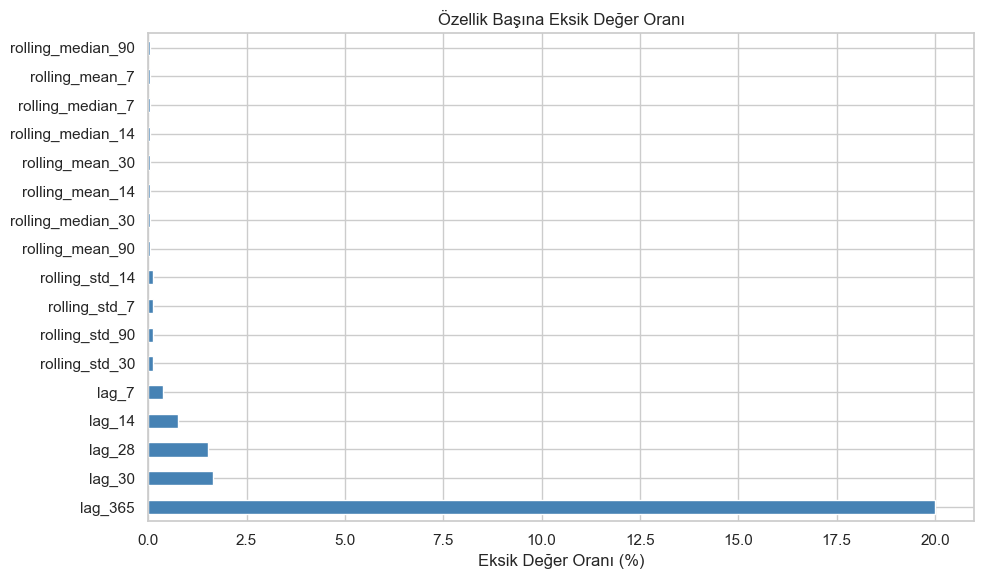

In [9]:
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(2)

null_df = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
null_df = null_df[null_df['null_count'] > 0].sort_values('null_pct', ascending=False)

print('Eksik değer içeren sütunlar:')
display(null_df)

# Görselleştir
if not null_df.empty:
    fig, ax = plt.subplots(figsize=(10, max(4, len(null_df) * 0.35)))
    null_df['null_pct'].plot.barh(ax=ax, color='steelblue')
    ax.set_xlabel('Eksik Değer Oranı (%)')
    ax.set_title('Özellik Başına Eksik Değer Oranı')
    plt.tight_layout()
    plt.show()

### Eksik Değerlerin Doldurulması

Lag ve rolling özellikler, her store×item serisinin başında kaçınılmaz olarak NaN içerir. Bu satırları modelleme aşamasında dışarıda bırakmak yerine **0** ile dolduruyoruz — satış başlamadan önceki dönemi "sıfır beklenti" olarak yorumluyoruz.

In [10]:
lag_roll_cols = [c for c in df.columns
                 if c.startswith('lag_') or c.startswith('rolling_')]

df[lag_roll_cols] = df[lag_roll_cols].fillna(0)

remaining_nulls = df.isnull().sum().sum()
print(f'Doldurma sonrası toplam NaN: {remaining_nulls}')

Doldurma sonrası toplam NaN: 0


## 9. Korelasyon Analizi (Hedef Değişken ile)

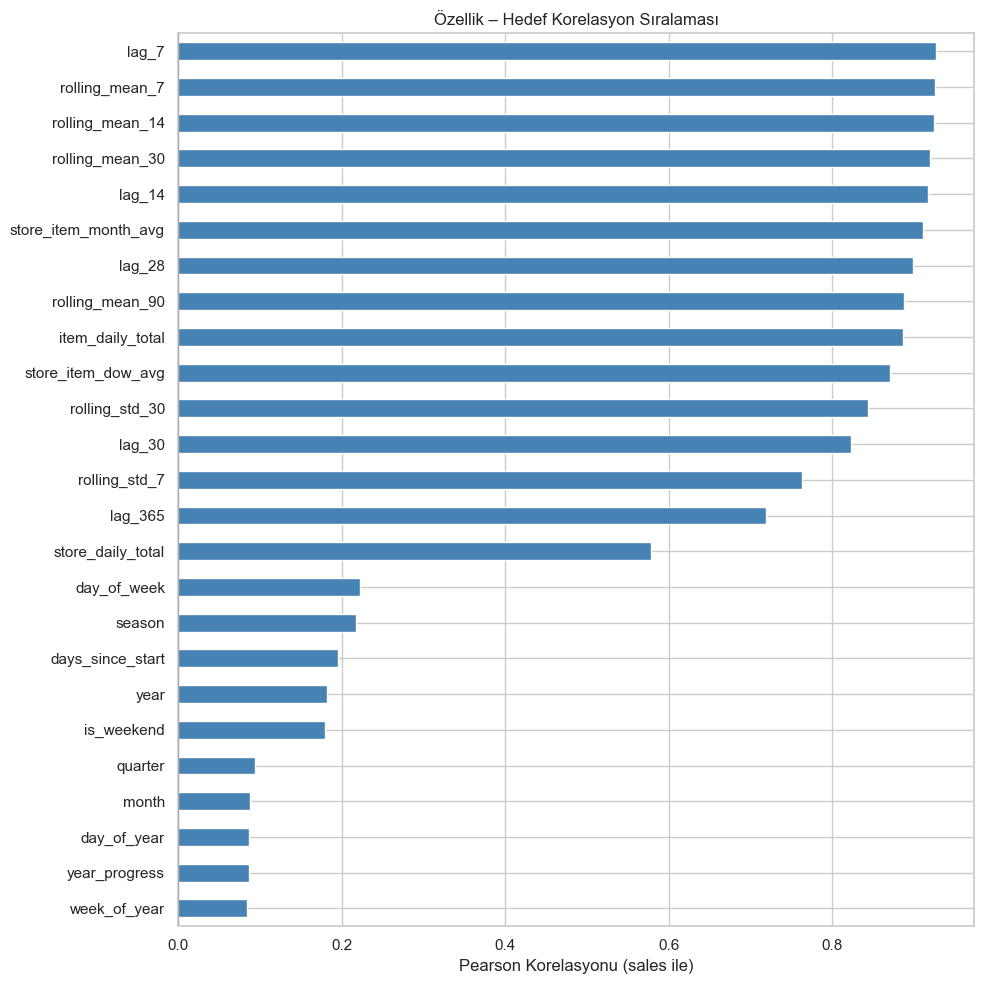


En yüksek 10 korelasyon:
lag_7                   0.927097
rolling_mean_7          0.925501
rolling_mean_14         0.925111
rolling_mean_30         0.919858
lag_14                  0.917537
store_item_month_avg    0.910862
lag_28                  0.898616
rolling_mean_90         0.888379
item_daily_total        0.886192
store_item_dow_avg      0.870985


In [11]:
numeric_features = [
    'month', 'day_of_week', 'week_of_year', 'year', 'day_of_year',
    'is_weekend', 'season', 'quarter',
    'days_since_start', 'year_progress',
    'lag_7', 'lag_14', 'lag_28', 'lag_30', 'lag_365',
    'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30', 'rolling_mean_90',
    'rolling_std_7', 'rolling_std_30',
    'store_item_month_avg', 'store_item_dow_avg',
    'store_daily_total', 'item_daily_total',
]

corr = df[numeric_features + ['sales']].corr()['sales'].drop('sales').sort_values()

fig, ax = plt.subplots(figsize=(10, 10))
corr.plot.barh(ax=ax, color=corr.map(lambda x: 'steelblue' if x >= 0 else 'tomato'))
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Korelasyonu (sales ile)')
ax.set_title('Özellik – Hedef Korelasyon Sıralaması')
plt.tight_layout()
plt.show()

print('\nEn yüksek 10 korelasyon:')
print(corr.abs().sort_values(ascending=False).head(10).to_string())

## 10. Örnek: Tek Ürün Üzerinde Lag Görselleştirmesi

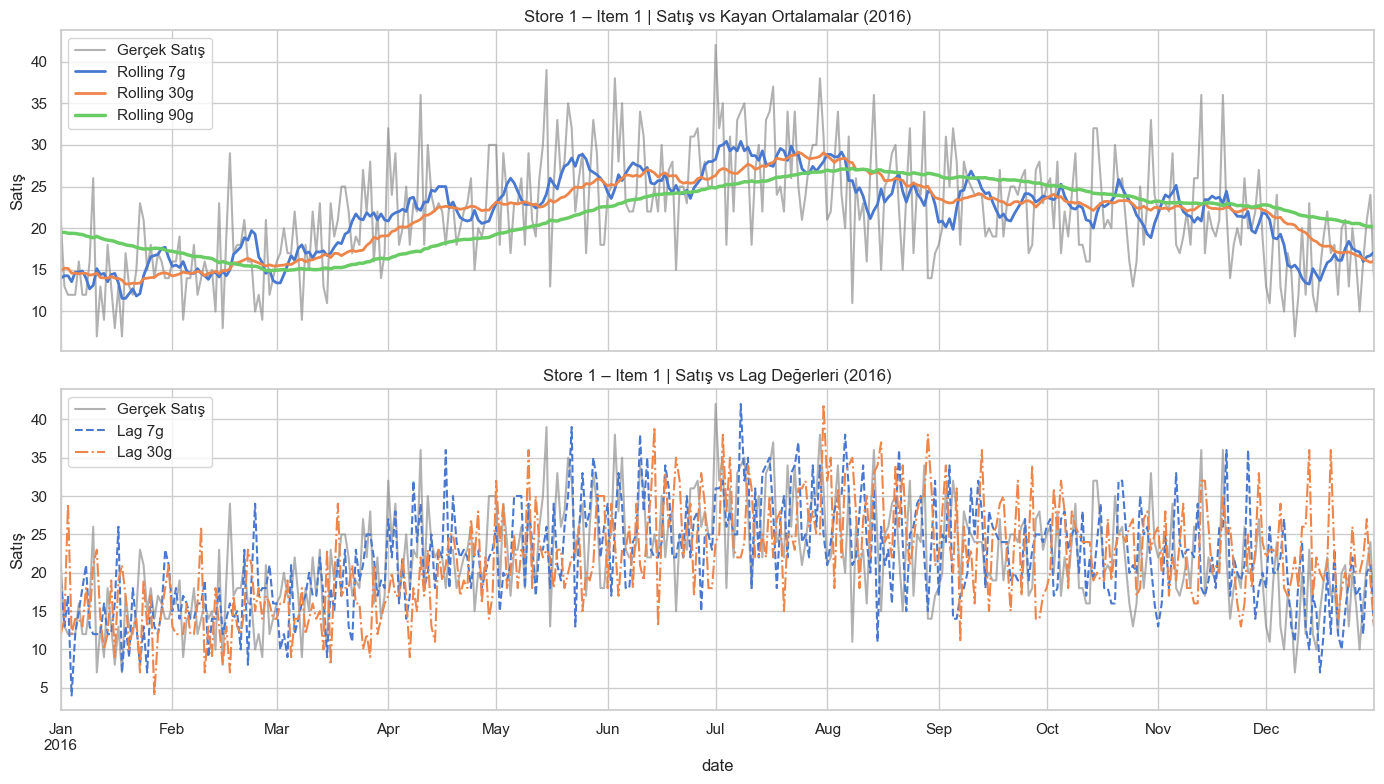

In [12]:
sample = df[(df['store'] == 1) & (df['item'] == 1)].set_index('date')
sample_2016 = sample.loc['2016-01-01':'2016-12-31']

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Orijinal vs rolling ortalamalar
sample_2016['sales'].plot(ax=axes[0], label='Gerçek Satış', alpha=0.6, color='gray')
sample_2016['rolling_mean_7'].plot(ax=axes[0], label='Rolling 7g', lw=2)
sample_2016['rolling_mean_30'].plot(ax=axes[0], label='Rolling 30g', lw=2)
sample_2016['rolling_mean_90'].plot(ax=axes[0], label='Rolling 90g', lw=2.5)
axes[0].set_title('Store 1 – Item 1 | Satış vs Kayan Ortalamalar (2016)')
axes[0].legend()
axes[0].set_ylabel('Satış')

# Lag'lar
sample_2016['sales'].plot(ax=axes[1], label='Gerçek Satış', alpha=0.6, color='gray')
sample_2016['lag_7'].plot(ax=axes[1], label='Lag 7g', lw=1.5, linestyle='--')
sample_2016['lag_30'].plot(ax=axes[1], label='Lag 30g', lw=1.5, linestyle='-.')
axes[1].set_title('Store 1 – Item 1 | Satış vs Lag Değerleri (2016)')
axes[1].legend()
axes[1].set_ylabel('Satış')

plt.tight_layout()
plt.show()

## 11. İşlenmiş Veriyi Kaydetme

In [13]:
# store_item_id sütununu çıkar (parquet'e yazarken sorun çıkarabilir, gerektiğinde yeniden üretilebilir)
df_out = df.drop(columns=['store_item_id'])

output_path = PROCESSED_DIR / 'train_features.parquet'
df_out.to_parquet(output_path, index=False, engine='pyarrow', compression='snappy')

file_size_mb = output_path.stat().st_size / 1e6
print(f'Kaydedildi : {output_path}')
print(f'Dosya boyutu: {file_size_mb:.1f} MB')
print(f'Shape      : {df_out.shape}')
print(f'Sütunlar   : {df_out.columns.tolist()}')

Kaydedildi : ../data/processed/train_features.parquet
Dosya boyutu: 47.8 MB
Shape      : (913000, 44)
Sütunlar   : ['date', 'store', 'item', 'sales', 'year', 'month', 'day', 'day_of_week', 'week_of_year', 'day_of_year', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'season', 'month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos', 'week_of_year_sin', 'week_of_year_cos', 'days_since_start', 'year_progress', 'lag_7', 'lag_14', 'lag_28', 'lag_30', 'lag_365', 'rolling_mean_7', 'rolling_std_7', 'rolling_median_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_median_14', 'rolling_mean_30', 'rolling_std_30', 'rolling_median_30', 'rolling_mean_90', 'rolling_std_90', 'rolling_median_90', 'store_item_month_avg', 'store_item_dow_avg', 'store_daily_total', 'item_daily_total']


## 12. Özet

| Grup | # Özellik |
|------|-----------|
| Tarih / Mevsimsellik (ham + sin/cos) | 17 |
| Trend | 2 |
| Lag (7, 14, 28, 30, 365 gün) | 5 |
| Rolling Ortalama (7, 14, 30, 90 gün) | 4 |
| Rolling Std (7, 14, 30, 90 gün) | 4 |
| Rolling Median (7, 14, 30, 90 gün) | 4 |
| Etkileşim | 4 |
| **Toplam** | **40** |

Çıktı: `data/processed/train_features.parquet`  
Sonraki adım: `03_model_training.ipynb` — XGBoost / LightGBM ile talep tahmini modeli.